# RxRx3-core 数据检查

本 notebook 只读取原始 RxRx3-core 文件与可选的 MDS 输出；不会修改数据集。先运行前两节确认路径和元数据，再查看少量六通道图像。图像展示时使用各通道分位数拉伸，仅用于可视化，不代表模型输入预处理。

In [2]:
from pathlib import Path
from itertools import islice
from io import BytesIO
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display
from PIL import Image

from cellvit.data.decode import decode_well
from cellvit.data.source import iter_wells

DATA_ROOT = Path(os.environ.get("RXRX3_CORE_ROOT", "/home/xkj2006/CellPainting/rxrx3_core")).expanduser()
MDS_ROOT_TEXT = os.environ.get("RXRX3_MDS_ROOT", "")
PREVIEW_WELLS = 2

if not (DATA_ROOT / "metadata_rxrx3_core.csv").is_file():
    raise FileNotFoundError(
        f"找不到 {DATA_ROOT / 'metadata_rxrx3_core.csv'}。"
        "请修改 DATA_ROOT 或设置 RXRX3_CORE_ROOT。"
    )
shards = sorted((DATA_ROOT / "data").glob("train-*.parquet"))
if not shards:
    raise FileNotFoundError(f"找不到图像分片：{DATA_ROOT / 'data'}")
print("数据目录:", DATA_ROOT)
print("Parquet 分片:", len(shards))
print("MDS 目录:", MDS_ROOT_TEXT or "未设置（可选）")

数据目录: /home/xkj2006/CellPainting/rxrx3_core
Parquet 分片: 35
MDS 目录: 未设置（可选）


## 1. 元数据规模与缺失值

只加载约 25 MB 的 CSV 元数据，不读取图像字节。

In [3]:
metadata = pd.read_csv(DATA_ROOT / "metadata_rxrx3_core.csv", low_memory=False)
metadata["concentration_um"] = pd.to_numeric(metadata["concentration"], errors="coerce")

overview = pd.Series({
    "孔位数": len(metadata),
    "唯一 well_id": metadata["well_id"].nunique(),
    "实验数": metadata["experiment_name"].nunique(),
    "实验-孔板组合数": metadata[["experiment_name", "plate"]].drop_duplicates().shape[0],
    "细胞类型数": metadata["cell_type"].nunique(),
    "CRISPR 孔位": int((metadata["perturbation_type"] == "CRISPR").sum()),
    "化合物孔位": int((metadata["perturbation_type"] == "COMPOUND").sum()),
})
display(overview.to_frame("数量"))
display(metadata.head(5))
display(metadata.isna().sum().sort_values(ascending=False).to_frame("缺失值个数"))

,数量
孔位数,222601
唯一 well_id,222601
实验数,180
实验-孔板组合数,1744
细胞类型数,1
CRISPR 孔位,126900
化合物孔位,95701


,well_id,experiment_name,plate,address,gene,treatment,SMILES,concentration,perturbation_type,cell_type,well_type_label,concentration_um
0,compound-001_10_AA12,compound-001,10,AA12,NaN,Esomeprazole,COC1=CC2=C([N-]C(=N2)[S@@](=O)CC2=C(C)C(OC)=C(...,2.50,COMPOUND,HUVEC,Control Compounds + Intron control,2.50
1,compound-001_10_AA14,compound-001,10,AA14,NaN,methylnaltrexone,C[N@@+]1(CC2CC2)CC[C@@]23[C@H]4OC5=C2C(C[C@@H]...,10.00,COMPOUND,HUVEC,Query Compounds + Intron control,10.00
2,compound-001_10_AA15,compound-001,10,AA15,NaN,EMPTY_control,NaN,NaN,COMPOUND,HUVEC,NaN,NaN
3,compound-001_10_AA20,compound-001,10,AA20,NaN,MI-773,CC(C)(C)CC1NC(C(C2=C(F)C(Cl)=CC=C2)C11C(=O)NC2...,0.25,COMPOUND,HUVEC,Control Compounds + Intron control,0.25
4,compound-001_10_AA21,compound-001,10,AA21,NaN,CRISPR_control,NaN,NaN,COMPOUND,HUVEC,CRISPR Gene Positive Controls,NaN


,缺失值个数
SMILES,159196
concentration,159196
concentration_um,159196
gene,95701
well_type_label,35546
well_id,0
experiment_name,0
plate,0
address,0
treatment,0


## 2. 扰动与浓度分布

,孔位数
well_type_label,
Query guides,76629
Query Compounds + Intron control,56700
(空),35546
CRISPR Gene Positive Controls,23507
Intron controls,11883
Control Compounds + Intron control,9589
Exon controls,8747


,化合物孔位数
concentration_um,
0.0020,4
0.0025,6732
0.0100,6733
0.0250,6727
0.0260,4
0.1000,6727
0.2500,11527
0.2600,4
1.0000,6734


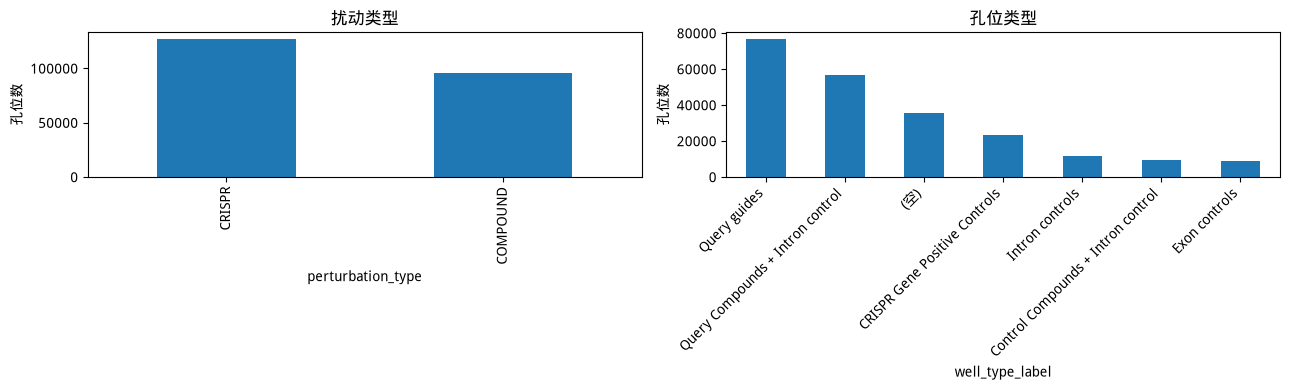

In [11]:
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

display(metadata["well_type_label"].fillna("(空)").value_counts().to_frame("孔位数"))
dose_counts = (
    metadata.loc[metadata["perturbation_type"] == "COMPOUND", "concentration_um"]
    .value_counts(dropna=False)
    .sort_index()
)
display(dose_counts.to_frame("化合物孔位数"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
metadata["perturbation_type"].value_counts().plot.bar(ax=axes[0], title="扰动类型")
metadata["well_type_label"].fillna("(空)").value_counts().plot.bar(
    ax=axes[1], title="孔位类型"
)
for ax in axes:
    ax.set_ylabel("孔位数")
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

## 3. 图像分片统计

只读取 Parquet 的文件元信息；这里不会解码全部图像。每孔预期六个单通道 JP2 文件。

In [5]:
shard_info = pd.DataFrame([
    {
        "分片": path.name,
        "通道图像行数": pq.ParquetFile(path).metadata.num_rows,
        "文件大小_GB": round(path.stat().st_size / 1e9, 3),
    }
    for path in shards
])
display(shard_info.head(10))
print("总通道图像行数:", int(shard_info["通道图像行数"].sum()))
print("元数据孔位 × 6:", len(metadata) * 6)
print("分片总大小 GB:", round(shard_info["文件大小_GB"].sum(), 2))

,分片,通道图像行数,文件大小_GB
0,train-00000-of-00035.parquet,38161,0.498
1,train-00001-of-00035.parquet,38161,0.498
2,train-00002-of-00035.parquet,38161,0.497
3,train-00003-of-00035.parquet,38161,0.498
4,train-00004-of-00035.parquet,38161,0.498
5,train-00005-of-00035.parquet,38161,0.498
6,train-00006-of-00035.parquet,38160,0.496
7,train-00007-of-00035.parquet,38160,0.496
8,train-00008-of-00035.parquet,38160,0.497
9,train-00009-of-00035.parquet,38160,0.497


总通道图像行数: 1335606
元数据孔位 × 6: 1335606
分片总大小 GB: 17.39


## 4. 查看六通道原始图像

只从排序后的分片开头读取 `PREVIEW_WELLS` 个孔位。每幅图的标题显示通道号和原始强度范围；展示图采用独立分位数拉伸。

预览孔位: ['compound-001_1_AA15', 'compound-001_1_AA16']


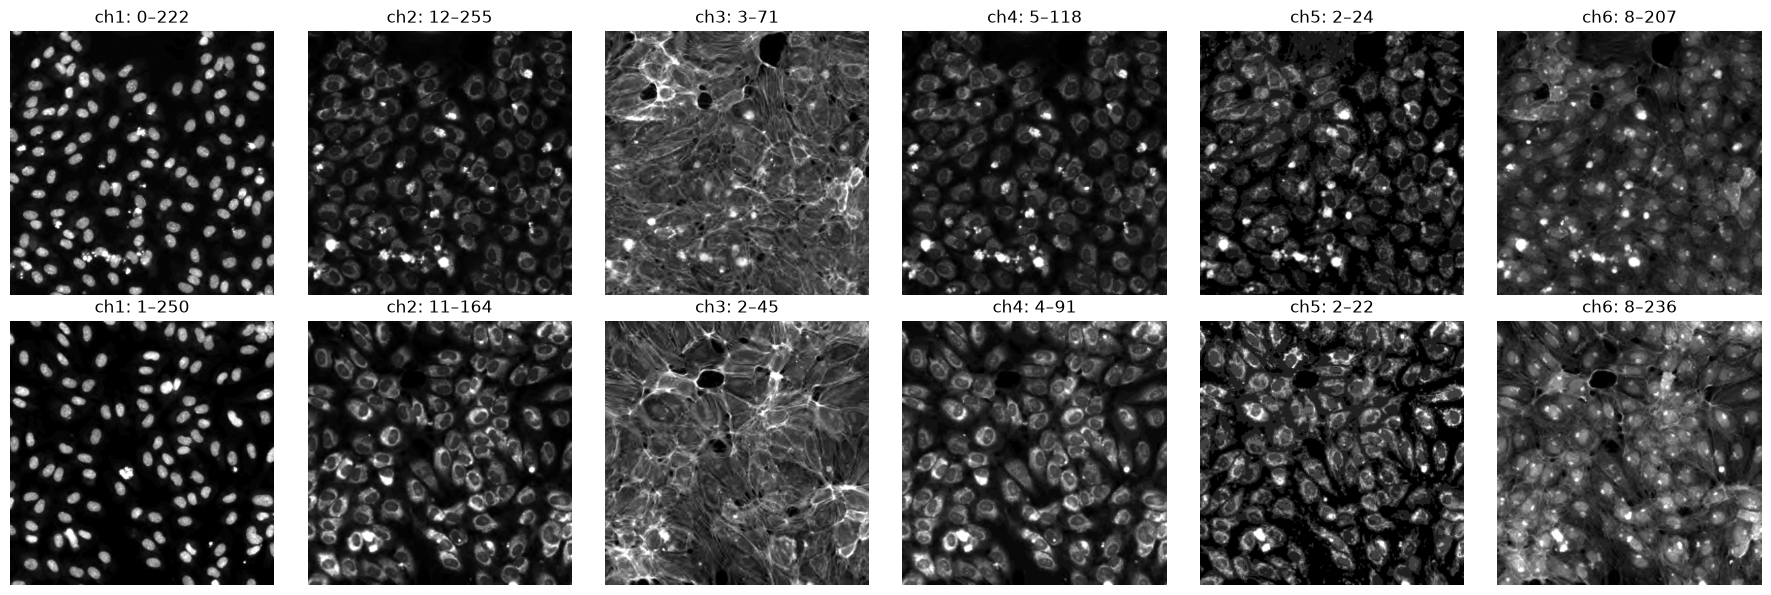

In [6]:
preview_wells = list(islice(iter_wells(shards), PREVIEW_WELLS))
print("预览孔位:", [well.key.well_id for well in preview_wells])

def channel_array(data: bytes) -> np.ndarray:
    with Image.open(BytesIO(data)) as image:
        return np.array(image)

def display_scale(image: np.ndarray) -> np.ndarray:
    low, high = np.percentile(image, [1, 99.5])
    if high <= low:
        high = low + 1
    return np.clip((image.astype(np.float32) - low) / (high - low), 0, 1)

fig, axes = plt.subplots(len(preview_wells), 6, figsize=(18, 3 * len(preview_wells)))
axes = np.atleast_2d(axes)
for row_index, well in enumerate(preview_wells):
    for channel_index, raw in enumerate(well.channels):
        image = channel_array(raw)
        ax = axes[row_index, channel_index]
        ax.imshow(display_scale(image), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"ch{channel_index + 1}: {image.min()}–{image.max()}")
        ax.axis("off")
    axes[row_index, 0].set_ylabel(well.key.well_id)
plt.tight_layout()
plt.show()

## 5. 伪彩合成与完整模型输入

伪彩仅用于直观检查：通道 6→红、通道 3→绿、通道 1→蓝；不代表真实显微镜颜色或生物学染料名称。DataLoader 返回完整的 6×512×512 图像；计划中的 ViT 在模型内部使用 16×16 patch。

完整模型输入形状: (6, 512, 512) dtype: float32
孔位元数据:


,well_id,experiment_name,plate,address,gene,treatment,SMILES,concentration,perturbation_type,cell_type,well_type_label,concentration_um
5976,compound-001_1_AA15,compound-001,1,AA15,NaN,EMPTY_control,NaN,NaN,COMPOUND,HUVEC,NaN,NaN


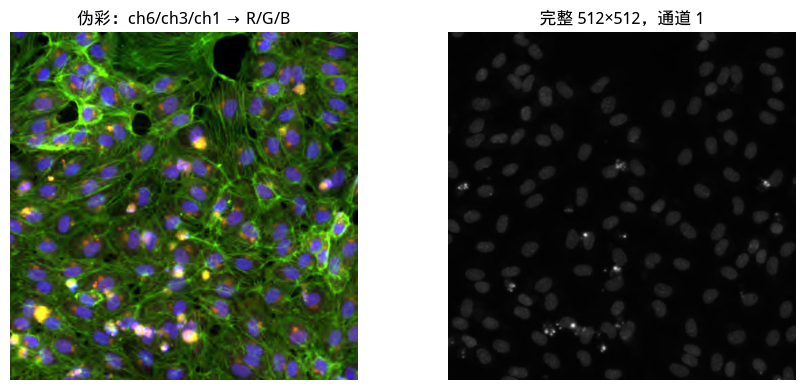

In [12]:
well = preview_wells[0]
arrays = [channel_array(raw) for raw in well.channels]
rgb = np.stack(
    [display_scale(arrays[5]), display_scale(arrays[2]), display_scale(arrays[0])],
    axis=-1,
)
full_image = decode_well({f"ch{i}": raw for i, raw in enumerate(well.channels, 1)})
print("完整模型输入形状:", full_image.shape, "dtype:", full_image.dtype)
print("孔位元数据:")
display(metadata.loc[metadata["well_id"] == well.key.well_id].head(1))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(rgb)
axes[0].set_title("伪彩：ch6/ch3/ch1 → R/G/B")
axes[1].imshow(full_image[0], cmap="gray")
axes[1].set_title("完整 512×512，通道 1")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. 可选：检查已转换的 MDS

先运行 `cellvit-convert`。然后设置 `RXRX3_MDS_ROOT` 指向转换后的根目录，再重启并运行此 notebook。未设置时此节会跳过。

In [8]:
if MDS_ROOT_TEXT:
    from cellvit.data.streaming_dataset import make_dataloader

    mds_root = Path(MDS_ROOT_TEXT).expanduser()
    manifest = json.loads((mds_root / "manifest.json").read_text(encoding="utf-8"))
    display(pd.Series(manifest["counts"], name="MDS 孔位数").to_frame())
    split = next(name for name, count in manifest["counts"].items() if count > 0)
    loader = make_dataloader(
        mds_root=mds_root,
        split=split,
        batch_size=2,
        num_workers=0,
        allow_incomplete=not manifest["complete"],
    )
    batch = next(iter(loader))
    print("MDS split:", split)
    print("batch image:", tuple(batch["image"].shape))
    print("well_id:", batch["well_id"])
else:
    print("未设置 RXRX3_MDS_ROOT，跳过 MDS 检查。")

未设置 RXRX3_MDS_ROOT，跳过 MDS 检查。
